# Hegselmann--Krause parameter screening

This notebook searches a small grid of Hegselmann--Krause confidence radii
\(\varepsilon\) and identifies regimes in which targeted intervention has a
consistent advantage over uniform budget allocation.

The notebook deliberately does **not** train either graph identifier. Its role
is to calibrate the environment before the expensive identification/control
experiments.

Policies:

- **no control**
- **uniform allocation**
- **static true-graph centrality**
- **HK state-aware centrality**, computed from the currently active
  bounded-confidence interaction graph

The state-aware policy is a diagnostic for parameter selection, not a proposed
final benchmark. It tells us whether an HK regime contains exploitable
state-dependent structure that a nonlinear identifier could potentially learn.


In [6]:
from __future__ import annotations

import inspect
import json
import math
import random
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find the repository root containing opinion_dynamics/. "
        "Place this notebook inside the repository or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_eigenvector_centrality,
    compute_laplacian,
)
from opinion_dynamics.baseline import centrality_based_continuous_control
from opinion_dynamics.utils.env_setup import EnvironmentFactory


REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration

The default settings match the current online experiments:

- campaign 0 is passive;
- 19 controlled campaigns follow;
- the total controlled budget is fixed at 6;
- the same graph and initial state are reused across all \(\varepsilon\) values
  and policies.

Set `QUICK_RUN = True` for a one-graph, one-initial-state smoke test.


In [7]:
STUDY_DATE = "2026_07_28"
STUDY_NAME = "hk_parameter_screen"

RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

QUICK_RUN = False
FAIL_FAST = True

# Ten candidate HK confidence radii.
HK_EPSILONS = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.75,
    1.00,
]
HK_INCLUDE_SELF = True

if QUICK_RUN:
    TOPOLOGY_SEEDS = [3]
    INITIAL_PERMUTATION_SEEDS = [0]
else:
    TOPOLOGY_SEEDS = [3, 4, 5]
    INITIAL_PERMUTATION_SEEDS = [0, 1, 2]

# Paper-style environment and campaign constants.
OMEGA = 1.0
U_BAR = 0.2
NUM_CAMPAIGNS_TOTAL = 20
T_CAMPAIGN = 0.5
T_S = 0.1
TOTAL_CONTROLLED_BUDGET = 6.0
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)
ZERO_FIRST_CAMPAIGN = True

INITIAL_STATE_SEED_BASE = 920_000
CLUSTER_TOLERANCE = 1e-3

POLICY_NOCONTROL = "no_control"
POLICY_UNIFORM = "uniform"
POLICY_STATIC = "true_graph_centrality"
POLICY_HK_AWARE = "hk_state_aware"

POLICY_ORDER = [
    POLICY_NOCONTROL,
    POLICY_UNIFORM,
    POLICY_STATIC,
    POLICY_HK_AWARE,
]

POLICY_LABELS = {
    POLICY_NOCONTROL: "no control",
    POLICY_UNIFORM: "uniform",
    POLICY_STATIC: "static true-graph centrality",
    POLICY_HK_AWARE: "HK state-aware centrality",
}

PRIMARY_TARGET_POLICY = POLICY_HK_AWARE
MIN_TARGET_WIN_RATE = 2.0 / 3.0
TOP_EPSILONS_TO_PLOT = 3

print("Results directory:", RESULTS_DIR)
print("Conditions:", len(HK_EPSILONS) * len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS))
print("Rollouts:", len(HK_EPSILONS) * len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS) * len(POLICY_ORDER))
print("Campaign budget:", B_CAMPAIGN)


Results directory: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_hk_parameter_screen
Conditions: 90
Rollouts: 360
Campaign budget: 0.3157894736842105


## Environment and policy helpers

The graph topology is generated once per topology seed. Every HK radius and
policy receives a fresh environment with the same adjacency matrix and the same
initial opinion vector.

The HK state-aware matrix uses equal weights over currently active graph
neighbors, matching the bounded-confidence averaging rule. Self-influence is
included when `HK_INCLUDE_SELF=True`.


In [8]:
def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)


def make_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    return rng.permutation(np.linspace(0.0, 1.0, int(n), dtype=float))


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)

    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass

    env.opinions = x0.copy()

    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass


def copy_env_value(value: Any) -> Any:
    if isinstance(value, np.ndarray):
        return np.array(value, copy=True)
    if isinstance(value, list):
        return list(value)
    if isinstance(value, tuple):
        return tuple(value)
    return value


def filter_constructor_kwargs(
    env_class: type,
    kwargs: Dict[str, Any],
    *,
    required_keys: Iterable[str] = (),
) -> Dict[str, Any]:
    signature = inspect.signature(env_class.__init__)
    parameters = signature.parameters

    if any(
        parameter.kind == inspect.Parameter.VAR_KEYWORD
        for parameter in parameters.values()
    ):
        return dict(kwargs)

    accepted = {
        name
        for name, parameter in parameters.items()
        if name != "self"
        and parameter.kind
        in {
            inspect.Parameter.POSITIONAL_OR_KEYWORD,
            inspect.Parameter.KEYWORD_ONLY,
        }
    }

    missing_required = sorted(set(required_keys) - accepted)
    if missing_required:
        raise RuntimeError(
            "The installed NetworkGraph constructor does not support "
            f"{missing_required}. Update the local rl-envs-forge checkout "
            "before running this notebook."
        )

    return {key: value for key, value in kwargs.items() if key in accepted}


def make_topology_template(topology_seed: int) -> Any:
    factory = EnvironmentFactory()
    return factory.get_randomized_env(
        seed=int(topology_seed),
        dynamics_model="laplacian",
    )


def make_hk_env(
    topology_template: Any,
    *,
    epsilon: float,
    topology_seed: int,
) -> Any:
    n = int(topology_template.num_agents)

    kwargs: Dict[str, Any] = {
        "connectivity_matrix": np.array(
            topology_template.connectivity_matrix,
            copy=True,
        ),
        "num_agents": n,
        "max_u": np.full(n, U_BAR, dtype=float),
        "desired_opinion": float(OMEGA),
        "t_campaign": float(T_CAMPAIGN),
        "t_s": float(T_S),
        "dynamics_model": "hegselmannkrause",
        "initial_opinions": None,
        "initial_opinion_range": tuple(
            getattr(topology_template, "initial_opinion_range", (0.0, 1.0))
        ),
        "control_resistance": np.array(
            getattr(
                topology_template,
                "control_resistance",
                np.zeros(n, dtype=float),
            ),
            copy=True,
        ),
        "max_steps": int(getattr(topology_template, "max_steps", 10_000)),
        "opinion_end_tolerance": float(
            getattr(topology_template, "opinion_end_tolerance", 0.01)
        ),
        "control_beta": float(
            getattr(topology_template, "control_beta", 0.4)
        ),
        "normalize_reward": bool(
            getattr(topology_template, "normalize_reward", False)
        ),
        "terminal_reward": float(
            getattr(topology_template, "terminal_reward", 0.0)
        ),
        "terminate_when_converged": False,
        "budget": copy_env_value(
            getattr(topology_template, "budget", None)
        ),
        "use_delta_shaping": bool(
            getattr(topology_template, "use_delta_shaping", False)
        ),
        "delta_lambda": float(
            getattr(topology_template, "delta_lambda", 0.0)
        ),
        "seed": int(topology_seed),
        "hk_epsilon": float(epsilon),
        "hk_include_self": bool(HK_INCLUDE_SELF),
    }

    kwargs = filter_constructor_kwargs(
        topology_template.__class__,
        kwargs,
        required_keys={"hk_epsilon", "hk_include_self"},
    )
    return topology_template.__class__(**kwargs)


def sanitize_centrality(
    centrality: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    v = np.asarray(centrality, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

    if float(v.sum()) < 0:
        v = -v

    v = np.maximum(v, 0.0)
    total = float(v.sum())

    if total <= eps:
        v = np.abs(v)
        total = float(v.sum())

    if total <= eps:
        return np.full(v.shape, 1.0 / len(v), dtype=float)

    return v / total


def centrality_from_matrix(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    return sanitize_centrality(
        compute_eigenvector_centrality(
            compute_laplacian(matrix)
        )
    )


def uniform_budget_action(
    max_u: np.ndarray,
    budget: float,
) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    action = np.zeros_like(max_u)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(max_u.size, dtype=bool)

    while remaining > 1e-12 and active.any():
        active_indices = np.flatnonzero(active)
        share = remaining / len(active_indices)
        progressed = False

        for index in active_indices:
            available = float(max_u[index] - action[index])
            allocation = min(share, available)

            if allocation > 0:
                action[index] += allocation
                remaining -= allocation
                progressed = True

            if action[index] >= max_u[index] - 1e-12:
                active[index] = False

        if not progressed:
            break

    return action


def hk_effective_matrix(
    adjacency: np.ndarray,
    opinions: np.ndarray,
    epsilon: float,
    *,
    include_self: bool = True,
) -> np.ndarray:
    adjacency = np.asarray(adjacency, dtype=float)
    opinions = np.asarray(opinions, dtype=float).reshape(-1)
    n = opinions.size

    graph_neighbors = adjacency > 0
    if include_self:
        graph_neighbors = graph_neighbors.copy()
        np.fill_diagonal(graph_neighbors, True)

    pairwise_distance = np.abs(
        opinions[:, None] - opinions[None, :]
    )
    active = graph_neighbors & (pairwise_distance <= float(epsilon))

    weights = active.astype(float)
    row_sums = weights.sum(axis=1, keepdims=True)

    zero_rows = np.flatnonzero(row_sums[:, 0] <= 0)
    for row in zero_rows:
        weights[row, row] = 1.0

    return weights / weights.sum(axis=1, keepdims=True)


def active_graph_edge_fraction(
    adjacency: np.ndarray,
    opinions: np.ndarray,
    epsilon: float,
) -> float:
    adjacency = np.asarray(adjacency, dtype=float)
    opinions = np.asarray(opinions, dtype=float).reshape(-1)

    graph_edges = adjacency > 0
    edge_count = int(graph_edges.sum())
    if edge_count == 0:
        return 0.0

    pairwise_distance = np.abs(
        opinions[:, None] - opinions[None, :]
    )
    active_edges = graph_edges & (
        pairwise_distance <= float(epsilon)
    )
    return float(active_edges.sum() / edge_count)


def count_opinion_clusters(
    opinions: np.ndarray,
    tolerance: float = CLUSTER_TOLERANCE,
) -> int:
    sorted_opinions = np.sort(
        np.asarray(opinions, dtype=float).reshape(-1)
    )
    if sorted_opinions.size == 0:
        return 0

    return int(
        1
        + np.sum(
            np.diff(sorted_opinions) > float(tolerance)
        )
    )


## Rollout and metrics

All policies use the same campaign timing and per-campaign budget. Campaign 0
is passive so that the screening protocol remains aligned with the online
single-shot experiments.

The primary performance metric is the final average opinion because the target
is \(D=1\). The time-averaged opinion is retained as a secondary metric.


In [9]:
def choose_action(
    env: Any,
    *,
    policy: str,
    epsilon: float,
    static_centrality: np.ndarray,
) -> np.ndarray:
    max_u = np.asarray(env.max_u, dtype=float).reshape(-1)

    if policy == POLICY_NOCONTROL:
        return np.zeros(env.num_agents, dtype=float)

    if policy == POLICY_UNIFORM:
        return uniform_budget_action(max_u, B_CAMPAIGN)

    if policy == POLICY_STATIC:
        action, _ = centrality_based_continuous_control(
            env,
            B_CAMPAIGN,
            v=static_centrality,
        )
        return np.asarray(action, dtype=float)

    if policy == POLICY_HK_AWARE:
        effective_matrix = hk_effective_matrix(
            env.connectivity_matrix,
            env.opinions,
            epsilon,
            include_self=HK_INCLUDE_SELF,
        )
        state_centrality = centrality_from_matrix(
            effective_matrix
        )
        action, _ = centrality_based_continuous_control(
            env,
            B_CAMPAIGN,
            v=state_centrality,
        )
        return np.asarray(action, dtype=float)

    raise ValueError(f"Unknown policy: {policy}")


def run_policy_rollout(
    topology_template: Any,
    x0: np.ndarray,
    *,
    topology_seed: int,
    initial_seed: int,
    epsilon: float,
    policy: str,
) -> Dict[str, Any]:
    env = make_hk_env(
        topology_template,
        epsilon=epsilon,
        topology_seed=topology_seed,
    )
    env.reset()
    set_initial_state(env, x0)

    adjacency = np.asarray(
        env.connectivity_matrix,
        dtype=float,
    )
    static_centrality = centrality_from_matrix(adjacency)

    states = [np.asarray(x0, dtype=float).copy()]
    actions: List[np.ndarray] = []
    rewards: List[float] = []
    active_fractions = [
        active_graph_edge_fraction(adjacency, x0, epsilon)
    ]

    for campaign in range(NUM_CAMPAIGNS_TOTAL):
        if ZERO_FIRST_CAMPAIGN and campaign == 0:
            action = np.zeros(env.num_agents, dtype=float)
        else:
            action = choose_action(
                env,
                policy=policy,
                epsilon=epsilon,
                static_centrality=static_centrality,
            )

        x_next, reward, done, truncated, info = env.step(
            np.asarray(action, dtype=float)
        )

        x_next = np.asarray(x_next, dtype=float)
        states.append(x_next.copy())
        actions.append(np.asarray(action, dtype=float).copy())
        rewards.append(float(reward))
        active_fractions.append(
            active_graph_edge_fraction(
                adjacency,
                x_next,
                epsilon,
            )
        )

        if done or truncated:
            break

    states_array = np.asarray(states, dtype=float)
    actions_array = np.asarray(actions, dtype=float)
    mean_trajectory = states_array.mean(axis=1)
    time_axis = (
        np.arange(states_array.shape[0], dtype=float)
        * T_CAMPAIGN
    )

    if time_axis[-1] > 0:
        time_average_mean = float(
            np.trapz(mean_trajectory, time_axis)
            / time_axis[-1]
        )
    else:
        time_average_mean = float(mean_trajectory[-1])

    final_state = states_array[-1]

    return {
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "epsilon": float(epsilon),
        "policy": policy,
        "states": states_array,
        "actions": actions_array,
        "rewards": np.asarray(rewards, dtype=float),
        "times": time_axis,
        "active_fractions": np.asarray(
            active_fractions,
            dtype=float,
        ),
        "final_mean": float(final_state.mean()),
        "time_average_mean": time_average_mean,
        "final_target_mae": float(
            np.mean(np.abs(OMEGA - final_state))
        ),
        "final_std": float(final_state.std()),
        "final_min": float(final_state.min()),
        "final_max": float(final_state.max()),
        "final_cluster_count": count_opinion_clusters(
            final_state
        ),
        "initial_active_edge_fraction": float(
            active_fractions[0]
        ),
        "mean_active_edge_fraction": float(
            np.mean(active_fractions)
        ),
        "total_reward": float(np.sum(rewards)),
    }


def scalar_trial_row(
    rollout: Dict[str, Any],
) -> Dict[str, Any]:
    excluded = {
        "states",
        "actions",
        "rewards",
        "times",
        "active_fractions",
    }
    return {
        key: value
        for key, value in rollout.items()
        if key not in excluded
    }


def trajectory_rows(
    rollout: Dict[str, Any],
) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []

    for boundary_index, (
        time_value,
        state,
        active_fraction,
    ) in enumerate(
        zip(
            rollout["times"],
            rollout["states"],
            rollout["active_fractions"],
        )
    ):
        rows.append(
            {
                "topology_seed": rollout["topology_seed"],
                "initial_seed": rollout["initial_seed"],
                "epsilon": rollout["epsilon"],
                "policy": rollout["policy"],
                "boundary_index": int(boundary_index),
                "time": float(time_value),
                "mean_opinion": float(np.mean(state)),
                "std_opinion": float(np.std(state)),
                "min_opinion": float(np.min(state)),
                "max_opinion": float(np.max(state)),
                "active_edge_fraction": float(active_fraction),
            }
        )

    return rows


## Preflight

This cell checks that the installed environment supports the HK-specific
constructor arguments and returns valid trajectories before the full sweep.


In [10]:
template = make_topology_template(TOPOLOGY_SEEDS[0])
x0_preflight = make_initial_opinions(
    template.num_agents,
    INITIAL_PERMUTATION_SEEDS[0],
)

preflight = run_policy_rollout(
    template,
    x0_preflight,
    topology_seed=TOPOLOGY_SEEDS[0],
    initial_seed=INITIAL_PERMUTATION_SEEDS[0],
    epsilon=HK_EPSILONS[0],
    policy=POLICY_NOCONTROL,
)

assert np.isfinite(preflight["states"]).all()
assert np.all(preflight["states"] >= -1e-9)
assert np.all(preflight["states"] <= 1.0 + 1e-9)
assert preflight["states"].shape[1] == template.num_agents

print("Preflight passed")
print("Agents:", template.num_agents)
print("Campaign boundaries:", preflight["states"].shape[0])
print("Initial active-edge fraction:", preflight["initial_active_edge_fraction"])


Preflight passed
Agents: 15
Campaign boundaries: 21
Initial active-edge fraction: 0.0


## Run the screening sweep

The outer loop is the confidence radius. For each \(\varepsilon\), all graph
and initial-state pairs are evaluated with the same four policies.


In [11]:
trial_rows: List[Dict[str, Any]] = []
trajectory_rows_all: List[Dict[str, Any]] = []
failed_rows: List[Dict[str, Any]] = []

total_conditions = (
    len(HK_EPSILONS)
    * len(TOPOLOGY_SEEDS)
    * len(INITIAL_PERMUTATION_SEEDS)
)
condition_index = 0

for epsilon in HK_EPSILONS:
    print(f"\nHK epsilon = {epsilon:.3f}")

    for topology_seed in TOPOLOGY_SEEDS:
        topology_template = make_topology_template(
            topology_seed
        )

        for initial_seed in INITIAL_PERMUTATION_SEEDS:
            condition_index += 1
            x0 = make_initial_opinions(
                topology_template.num_agents,
                initial_seed,
            )

            try:
                for policy in POLICY_ORDER:
                    rollout = run_policy_rollout(
                        topology_template,
                        x0,
                        topology_seed=topology_seed,
                        initial_seed=initial_seed,
                        epsilon=epsilon,
                        policy=policy,
                    )
                    trial_rows.append(
                        scalar_trial_row(rollout)
                    )
                    trajectory_rows_all.extend(
                        trajectory_rows(rollout)
                    )

            except Exception as exc:
                failed_rows.append(
                    {
                        "epsilon": float(epsilon),
                        "topology_seed": int(topology_seed),
                        "initial_seed": int(initial_seed),
                        "error_type": type(exc).__name__,
                        "error_message": str(exc),
                    }
                )
                if FAIL_FAST:
                    raise

            print(
                f"  condition {condition_index:>3}/{total_conditions}: "
                f"topology={topology_seed}, initial={initial_seed}"
            )

trials_df = pd.DataFrame(trial_rows)
trajectories_df = pd.DataFrame(
    trajectory_rows_all
)
failed_df = pd.DataFrame(failed_rows)

print("\nCompleted rollouts:", len(trials_df))
print("Failed conditions:", len(failed_df))



HK epsilon = 0.050
  condition   1/90: topology=3, initial=0
  condition   2/90: topology=3, initial=1
  condition   3/90: topology=3, initial=2
  condition   4/90: topology=4, initial=0
  condition   5/90: topology=4, initial=1
  condition   6/90: topology=4, initial=2
  condition   7/90: topology=5, initial=0
  condition   8/90: topology=5, initial=1
  condition   9/90: topology=5, initial=2

HK epsilon = 0.100
  condition  10/90: topology=3, initial=0
  condition  11/90: topology=3, initial=1
  condition  12/90: topology=3, initial=2
  condition  13/90: topology=4, initial=0
  condition  14/90: topology=4, initial=1
  condition  15/90: topology=4, initial=2
  condition  16/90: topology=5, initial=0
  condition  17/90: topology=5, initial=1
  condition  18/90: topology=5, initial=2

HK epsilon = 0.150
  condition  19/90: topology=3, initial=0
  condition  20/90: topology=3, initial=1
  condition  21/90: topology=3, initial=2
  condition  22/90: topology=4, initial=0
  condition  23/

## Paired comparison and parameter ranking

The primary paired quantity is

\[
J_{\mathrm{HK-aware}} - J_{\mathrm{uniform}}
\]

computed for the same \(\varepsilon\), graph, and initial state.

A useful setting should also improve over no control and should win against
uniform in most trials. The `selection_score` is intentionally simple:

\[
\text{median gap over uniform}
\times
\text{win rate over uniform}
\]

Configurations meeting the minimum win-rate and positive median improvement
over no control are marked as eligible.


In [12]:
required_policies = set(POLICY_ORDER)
observed_policies = set(trials_df["policy"].unique())
missing_policies = required_policies - observed_policies
if missing_policies:
    raise RuntimeError(
        f"Missing policy results: {sorted(missing_policies)}"
    )

paired_df = (
    trials_df.pivot(
        index=[
            "epsilon",
            "topology_seed",
            "initial_seed",
        ],
        columns="policy",
        values="final_mean",
    )
    .reset_index()
)

paired_df["static_minus_uniform"] = (
    paired_df[POLICY_STATIC]
    - paired_df[POLICY_UNIFORM]
)
paired_df["hk_aware_minus_uniform"] = (
    paired_df[POLICY_HK_AWARE]
    - paired_df[POLICY_UNIFORM]
)
paired_df["hk_aware_minus_nocontrol"] = (
    paired_df[POLICY_HK_AWARE]
    - paired_df[POLICY_NOCONTROL]
)
paired_df["uniform_minus_nocontrol"] = (
    paired_df[POLICY_UNIFORM]
    - paired_df[POLICY_NOCONTROL]
)


def summarize_gap(
    group: pd.DataFrame,
    column: str,
    prefix: str,
) -> Dict[str, float]:
    values = group[column].to_numpy(dtype=float)
    count = len(values)
    std = float(np.std(values, ddof=1)) if count > 1 else 0.0

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_std": std,
        f"{prefix}_ci95": float(
            1.96 * std / math.sqrt(count)
        ) if count > 0 else float("nan"),
        f"{prefix}_win_rate": float(
            np.mean(values > 0)
        ),
        f"{prefix}_count": int(count),
    }


ranking_rows: List[Dict[str, Any]] = []

for epsilon, group in paired_df.groupby("epsilon"):
    row: Dict[str, Any] = {
        "epsilon": float(epsilon),
    }

    row.update(
        summarize_gap(
            group,
            "hk_aware_minus_uniform",
            "hk_aware_vs_uniform",
        )
    )
    row.update(
        summarize_gap(
            group,
            "static_minus_uniform",
            "static_vs_uniform",
        )
    )
    row.update(
        summarize_gap(
            group,
            "hk_aware_minus_nocontrol",
            "hk_aware_vs_nocontrol",
        )
    )
    row.update(
        summarize_gap(
            group,
            "uniform_minus_nocontrol",
            "uniform_vs_nocontrol",
        )
    )

    for policy in POLICY_ORDER:
        values = group[policy].to_numpy(dtype=float)
        row[f"{policy}_final_mean"] = float(
            np.mean(values)
        )

    no_control_diagnostics = trials_df[
        (trials_df["epsilon"] == epsilon)
        & (trials_df["policy"] == POLICY_NOCONTROL)
    ]

    row["initial_active_edge_fraction_mean"] = float(
        no_control_diagnostics[
            "initial_active_edge_fraction"
        ].mean()
    )
    row["no_control_mean_active_edge_fraction"] = float(
        no_control_diagnostics[
            "mean_active_edge_fraction"
        ].mean()
    )
    row["no_control_final_clusters_mean"] = float(
        no_control_diagnostics[
            "final_cluster_count"
        ].mean()
    )
    row["no_control_final_std_mean"] = float(
        no_control_diagnostics[
            "final_std"
        ].mean()
    )

    ranking_rows.append(row)

ranking_df = pd.DataFrame(ranking_rows)

ranking_df["eligible"] = (
    (
        ranking_df[
            "hk_aware_vs_uniform_win_rate"
        ]
        >= MIN_TARGET_WIN_RATE
    )
    & (
        ranking_df[
            "hk_aware_vs_nocontrol_median"
        ]
        > 0
    )
)

ranking_df["selection_score"] = (
    ranking_df[
        "hk_aware_vs_uniform_median"
    ]
    * ranking_df[
        "hk_aware_vs_uniform_win_rate"
    ]
)

ranking_df = ranking_df.sort_values(
    [
        "eligible",
        "selection_score",
        "hk_aware_vs_uniform_mean",
        "epsilon",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

recommended_epsilon = float(
    ranking_df.iloc[0]["epsilon"]
)

print("Recommended screening epsilon:", recommended_epsilon)


Recommended screening epsilon: 0.75


In [13]:
display_columns = [
    "epsilon",
    "eligible",
    "selection_score",
    "hk_aware_vs_uniform_mean",
    "hk_aware_vs_uniform_median",
    "hk_aware_vs_uniform_ci95",
    "hk_aware_vs_uniform_win_rate",
    "static_vs_uniform_mean",
    "static_vs_uniform_win_rate",
    "hk_aware_vs_nocontrol_mean",
    "uniform_vs_nocontrol_mean",
    "uniform_final_mean",
    "hk_state_aware_final_mean",
    "initial_active_edge_fraction_mean",
    "no_control_final_clusters_mean",
    "no_control_final_std_mean",
]

display(
    ranking_df[display_columns]
)


,epsilon,eligible,selection_score,hk_aware_vs_uniform_mean,hk_aware_vs_uniform_median,hk_aware_vs_uniform_ci95,hk_aware_vs_uniform_win_rate,static_vs_uniform_mean,static_vs_uniform_win_rate,hk_aware_vs_nocontrol_mean,uniform_vs_nocontrol_mean,uniform_final_mean,hk_state_aware_final_mean,initial_active_edge_fraction_mean,no_control_final_clusters_mean,no_control_final_std_mean
0,0.75,True,0.155237,0.154477,0.155237,0.028005,1.000000,0.155478,1.000000,0.312395,0.157918,0.683028,0.837505,0.910706,1.000000,2.763096e-07
1,1.00,True,0.140406,0.150952,0.140406,0.026468,1.000000,0.151895,1.000000,0.305627,0.154675,0.689538,0.840490,1.000000,1.000000,2.355215e-07
2,0.50,True,0.110657,0.121399,0.124489,0.066459,0.888889,0.128199,0.888889,0.300709,0.179311,0.669668,0.791066,0.739798,1.555556,8.992637e-02
3,0.40,True,0.082393,0.066648,0.105934,0.085185,0.777778,0.077872,0.888889,0.249813,0.183165,0.662896,0.729544,0.597866,3.111111,1.946489e-01
4,0.30,True,0.078173,0.078351,0.100508,0.075097,0.777778,0.096970,1.000000,0.238073,0.159722,0.666658,0.745009,0.495914,4.000000,2.483638e-01
5,0.25,False,0.008085,0.000355,0.014553,0.089232,0.555556,0.060853,0.777778,0.184978,0.184622,0.670904,0.671259,0.368425,6.333333,2.936725e-01
6,0.05,False,-0.000000,-0.086949,-0.074116,0.020691,0.000000,0.031539,1.000000,0.077745,0.164694,0.664694,0.577745,0.000000,15.000000,3.086067e-01
7,0.10,False,-0.007572,-0.057639,-0.068147,0.031447,0.111111,0.063969,1.000000,0.106242,0.163880,0.661532,0.603894,0.134603,11.888889,3.106673e-01
8,0.20,False,-0.037426,-0.043598,-0.084209,0.075170,0.444444,0.072204,0.888889,0.131569,0.175166,0.662935,0.619337,0.224019,8.222222,3.065269e-01
9,0.15,False,-0.039021,-0.044639,-0.087796,0.075596,0.444444,0.052425,0.888889,0.121381,0.166020,0.658013,0.613375,0.224019,9.111111,3.084798e-01


## Performance plots

Positive gaps mean that targeted intervention outperformed uniform allocation.
The confidence intervals are across paired graph/initial-state trials.


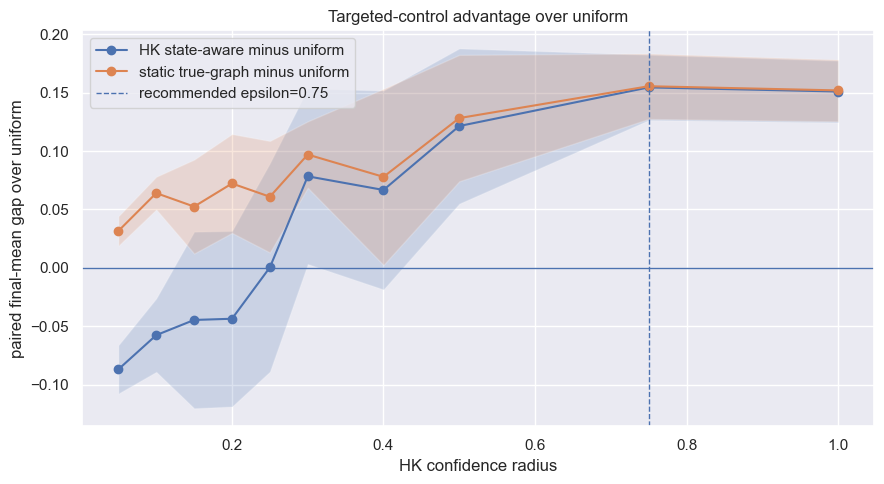

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for gap_column, label in [
    (
        "hk_aware_minus_uniform",
        "HK state-aware minus uniform",
    ),
    (
        "static_minus_uniform",
        "static true-graph minus uniform",
    ),
]:
    summary = (
        paired_df.groupby("epsilon")[gap_column]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("epsilon")
    )
    summary["ci95"] = (
        1.96
        * summary["std"].fillna(0.0)
        / np.sqrt(summary["count"])
    )

    x = summary["epsilon"].to_numpy(dtype=float)
    y = summary["mean"].to_numpy(dtype=float)
    error = summary["ci95"].to_numpy(dtype=float)

    ax.plot(x, y, marker="o", label=label)
    ax.fill_between(x, y - error, y + error, alpha=0.2)

ax.axhline(0.0, linewidth=1)
ax.axvline(
    recommended_epsilon,
    linestyle="--",
    linewidth=1,
    label=f"recommended epsilon={recommended_epsilon:g}",
)
ax.set_xlabel("HK confidence radius")
ax.set_ylabel("paired final-mean gap over uniform")
ax.set_title("Targeted-control advantage over uniform")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


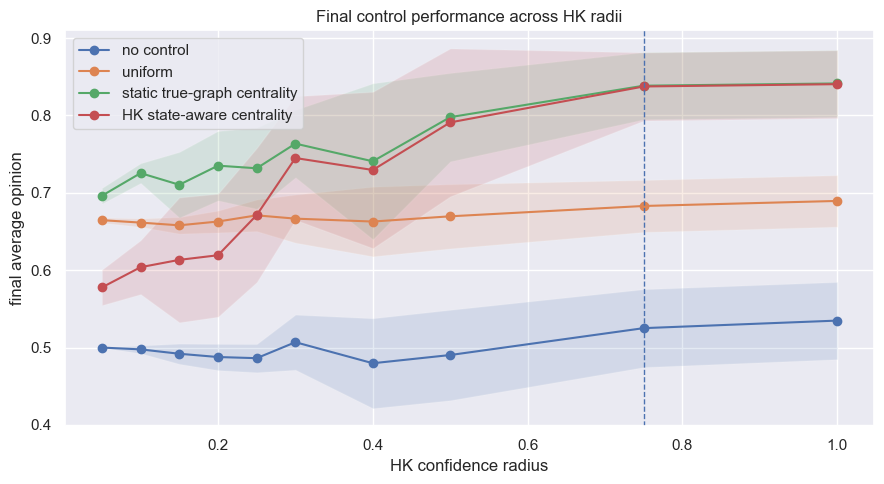

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

policy_summary = (
    trials_df.groupby(["epsilon", "policy"])["final_mean"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
policy_summary["ci95"] = (
    1.96
    * policy_summary["std"].fillna(0.0)
    / np.sqrt(policy_summary["count"])
)

for policy in POLICY_ORDER:
    sub = policy_summary[
        policy_summary["policy"] == policy
    ].sort_values("epsilon")

    x = sub["epsilon"].to_numpy(dtype=float)
    y = sub["mean"].to_numpy(dtype=float)
    error = sub["ci95"].to_numpy(dtype=float)

    ax.plot(
        x,
        y,
        marker="o",
        label=POLICY_LABELS[policy],
    )
    ax.fill_between(
        x,
        y - error,
        y + error,
        alpha=0.15,
    )

ax.axvline(
    recommended_epsilon,
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel("HK confidence radius")
ax.set_ylabel("final average opinion")
ax.set_title("Final control performance across HK radii")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


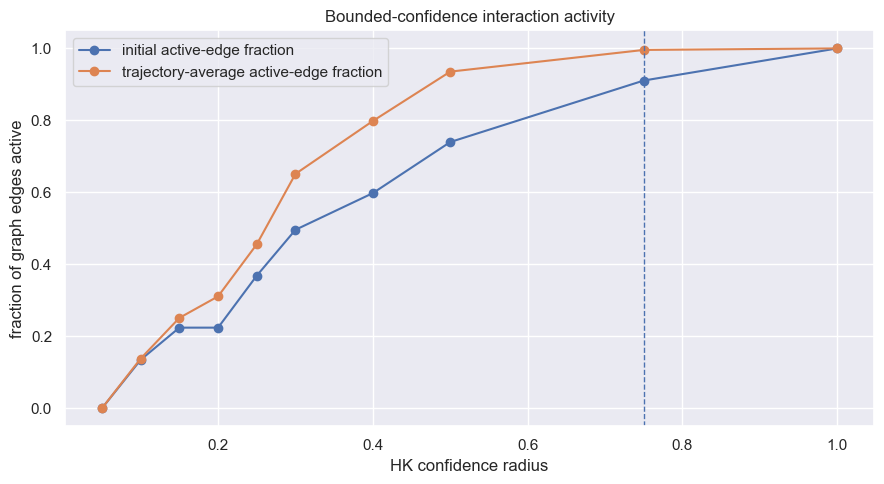

,epsilon,initial_active_fraction,mean_active_fraction,final_clusters
0,0.05,0.000000,0.000000,15.000000
1,0.10,0.134603,0.138016,11.888889
2,0.15,0.224019,0.251096,9.111111
3,0.20,0.224019,0.310907,8.222222
4,0.25,0.368425,0.455586,6.333333
5,0.30,0.495914,0.651224,4.000000
6,0.40,0.597866,0.798313,3.111111
7,0.50,0.739798,0.935470,1.555556
8,0.75,0.910706,0.995748,1.000000
9,1.00,1.000000,1.000000,1.000000


In [16]:
diagnostic_summary = (
    trials_df[
        trials_df["policy"] == POLICY_NOCONTROL
    ]
    .groupby("epsilon")
    .agg(
        initial_active_fraction=(
            "initial_active_edge_fraction",
            "mean",
        ),
        mean_active_fraction=(
            "mean_active_edge_fraction",
            "mean",
        ),
        final_clusters=(
            "final_cluster_count",
            "mean",
        ),
    )
    .reset_index()
    .sort_values("epsilon")
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    diagnostic_summary["epsilon"],
    diagnostic_summary["initial_active_fraction"],
    marker="o",
    label="initial active-edge fraction",
)
ax.plot(
    diagnostic_summary["epsilon"],
    diagnostic_summary["mean_active_fraction"],
    marker="o",
    label="trajectory-average active-edge fraction",
)
ax.axvline(
    recommended_epsilon,
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel("HK confidence radius")
ax.set_ylabel("fraction of graph edges active")
ax.set_title("Bounded-confidence interaction activity")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

display(diagnostic_summary)


## Trajectories for the highest-ranked radii

For each of the top-ranked \(\varepsilon\) values, the plot shows the median
average-opinion trajectory and its interquartile range across graph and
initial-state trials.


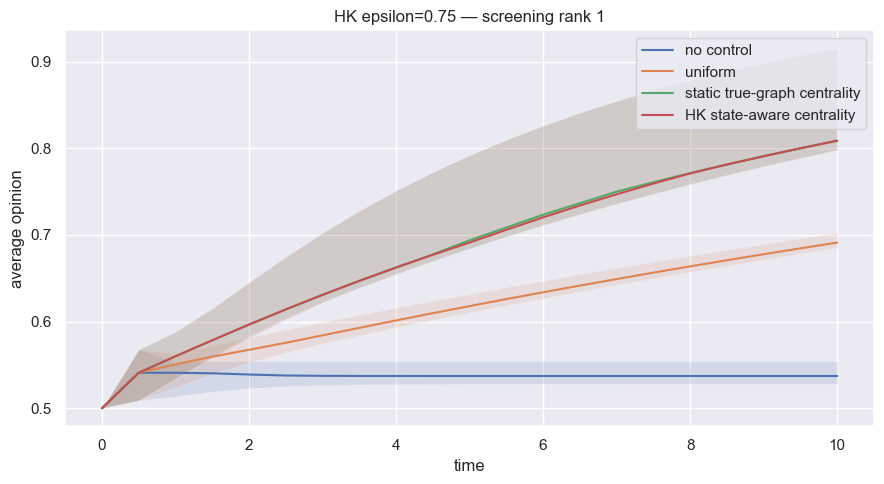

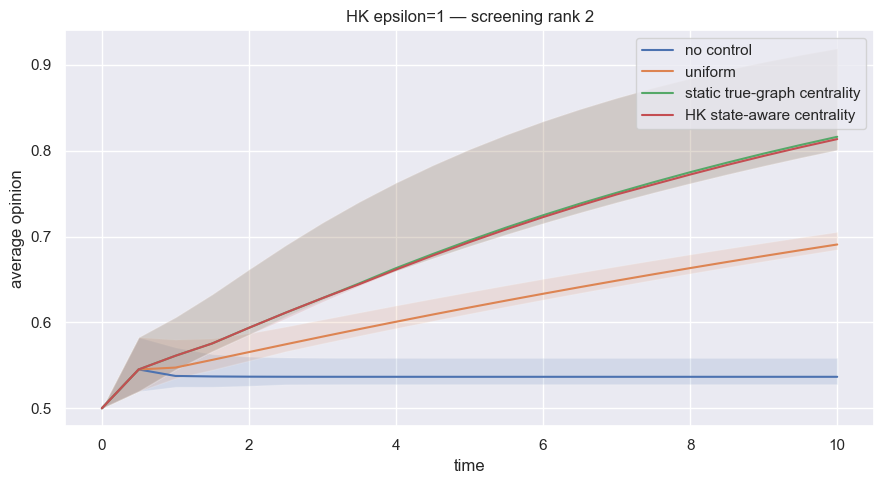

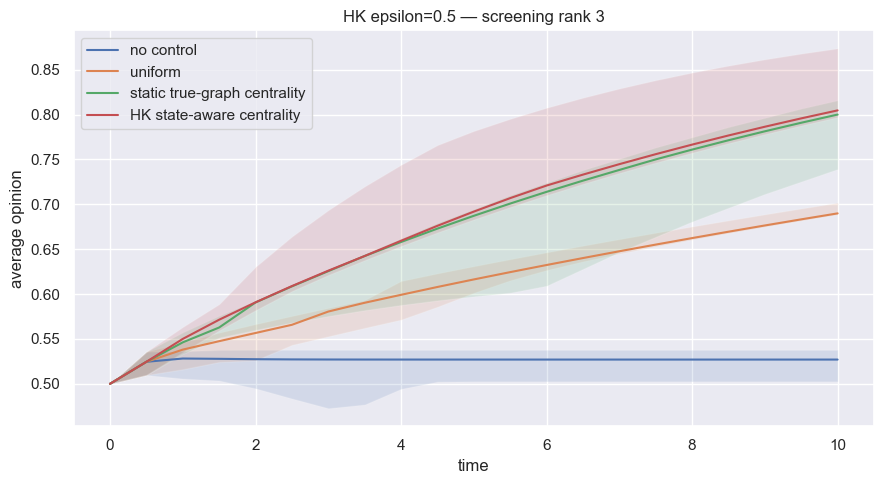

In [17]:
top_epsilons = (
    ranking_df.head(TOP_EPSILONS_TO_PLOT)["epsilon"]
    .astype(float)
    .tolist()
)

for epsilon in top_epsilons:
    fig, ax = plt.subplots(figsize=(9, 5))

    epsilon_data = trajectories_df[
        trajectories_df["epsilon"] == epsilon
    ]

    for policy in POLICY_ORDER:
        policy_data = epsilon_data[
            epsilon_data["policy"] == policy
        ]

        aggregated = (
            policy_data.groupby("boundary_index")
            .agg(
                time=("time", "first"),
                median=("mean_opinion", "median"),
                q25=(
                    "mean_opinion",
                    lambda values: values.quantile(0.25),
                ),
                q75=(
                    "mean_opinion",
                    lambda values: values.quantile(0.75),
                ),
            )
            .reset_index()
        )

        ax.plot(
            aggregated["time"],
            aggregated["median"],
            label=POLICY_LABELS[policy],
        )
        ax.fill_between(
            aggregated["time"],
            aggregated["q25"],
            aggregated["q75"],
            alpha=0.15,
        )

    rank_position = int(
        ranking_df.index[
            ranking_df["epsilon"] == epsilon
        ][0]
        + 1
    )
    ax.set_xlabel("time")
    ax.set_ylabel("average opinion")
    ax.set_title(
        f"HK epsilon={epsilon:g} — screening rank {rank_position}"
    )
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Representative trials for the recommended radius

The following figures show the worst, median, and best paired
HK-aware-minus-uniform trials for the selected radius. This reveals whether the
aggregate advantage is stable or driven by only a few graph/state pairs.


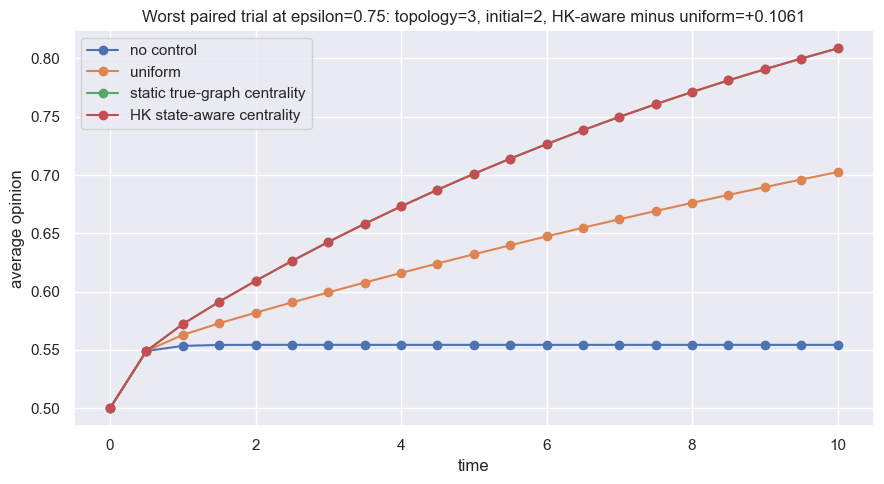

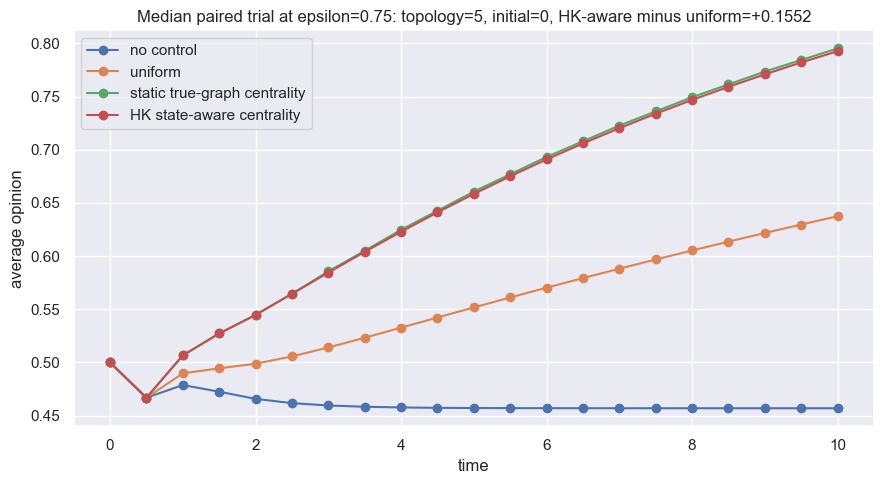

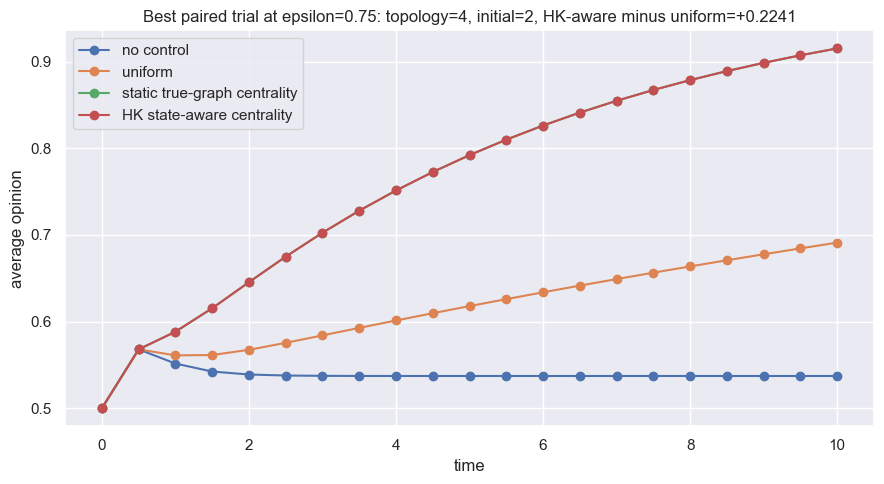

In [18]:
selected_pairs = paired_df[
    paired_df["epsilon"] == recommended_epsilon
].sort_values("hk_aware_minus_uniform").reset_index(drop=True)

representative_indices = sorted(
    {
        0,
        len(selected_pairs) // 2,
        len(selected_pairs) - 1,
    }
)

representative_labels = {
    representative_indices[0]: "worst",
    representative_indices[len(representative_indices) // 2]: "median",
    representative_indices[-1]: "best",
}

for row_index in representative_indices:
    pair_row = selected_pairs.iloc[row_index]
    topology_seed = int(pair_row["topology_seed"])
    initial_seed = int(pair_row["initial_seed"])
    gap = float(pair_row["hk_aware_minus_uniform"])

    trial_data = trajectories_df[
        (trajectories_df["epsilon"] == recommended_epsilon)
        & (
            trajectories_df["topology_seed"]
            == topology_seed
        )
        & (
            trajectories_df["initial_seed"]
            == initial_seed
        )
    ]

    fig, ax = plt.subplots(figsize=(9, 5))

    for policy in POLICY_ORDER:
        policy_data = trial_data[
            trial_data["policy"] == policy
        ].sort_values("boundary_index")

        ax.plot(
            policy_data["time"],
            policy_data["mean_opinion"],
            marker="o",
            label=POLICY_LABELS[policy],
        )

    label = representative_labels.get(
        row_index,
        "representative",
    )
    ax.set_xlabel("time")
    ax.set_ylabel("average opinion")
    ax.set_title(
        f"{label.capitalize()} paired trial at epsilon={recommended_epsilon:g}: "
        f"topology={topology_seed}, initial={initial_seed}, "
        f"HK-aware minus uniform={gap:+.4f}"
    )
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Save results

The raw trial table, trajectory table, paired comparisons, ranked parameter
table, failures, and experiment manifest are saved next to the other project
results.


In [ ]:
trials_path = RESULTS_DIR / "hk_parameter_screen_trials.csv"
trajectories_path = (
    RESULTS_DIR
    / "hk_parameter_screen_trajectories.csv"
)
paired_path = RESULTS_DIR / "hk_parameter_screen_paired.csv"
ranking_path = RESULTS_DIR / "hk_parameter_screen_ranking.csv"
failed_path = RESULTS_DIR / "hk_parameter_screen_failures.csv"
manifest_path = RESULTS_DIR / "hk_parameter_screen_manifest.json"

trials_df.to_csv(trials_path, index=False)
trajectories_df.to_csv(trajectories_path, index=False)
paired_df.to_csv(paired_path, index=False)
ranking_df.to_csv(ranking_path, index=False)
failed_df.to_csv(failed_path, index=False)

manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "study_name": STUDY_NAME,
    "dynamics_model": "hegselmannkrause",
    "hk_epsilons": HK_EPSILONS,
    "hk_include_self": HK_INCLUDE_SELF,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "omega": OMEGA,
    "u_bar": U_BAR,
    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "total_controlled_budget": TOTAL_CONTROLLED_BUDGET,
    "budget_per_controlled_campaign": B_CAMPAIGN,
    "zero_first_campaign": ZERO_FIRST_CAMPAIGN,
    "policies": POLICY_ORDER,
    "primary_target_policy": PRIMARY_TARGET_POLICY,
    "minimum_target_win_rate": MIN_TARGET_WIN_RATE,
    "recommended_epsilon": recommended_epsilon,
    "quick_run": QUICK_RUN,
}

manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print("Saved:")
for path in [
    trials_path,
    trajectories_path,
    paired_path,
    ranking_path,
    failed_path,
    manifest_path,
]:
    print(" -", path)

print("\nRecommended epsilon from this screening run:", recommended_epsilon)


Saved:
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_hk_parameter_screen\hk_parameter_screen_trials.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_hk_parameter_screen\hk_parameter_screen_trajectories.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_hk_parameter_screen\hk_parameter_screen_paired.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_hk_parameter_screen\hk_parameter_screen_ranking.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_hk_parameter_screen\hk_parameter_screen_failures.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_hk_parameter_screen\hk_parameter_screen_manifest.json

Recommended epsilon from this screening run: 0.75


: 

## Next step

After inspecting the ranking and trajectories, take the best two or three
confidence radii and confirm them on fresh topology and initial-state seeds.
Only after that confirmation should one radius be fixed for the full
identification and learned-control experiments.
